# Preprocessing Pipeline + Multiple Algorithms

This notebook builds on the earlier notes: **clean what's safe before the split, fit every learned statistic on train only, then compare several algorithms** using the same stored preprocessing parameters.

Flow:
1. Create a small, deliberately messy dataset (missing values, an impossible value, a duplicate row, mixed numeric/categorical columns)
2. Fix duplicates + invalid values (safe pre-split)
3. Train/test split
4. Build a `ColumnTransformer` preprocessing pipeline
5. Fit it on train only — this is where parameters get **learned and stored**
6. Persist the fitted preprocessor with `joblib`
7. Regression: **Linear Regression**
8. Classification: **Logistic Regression, Naive Bayes, Decision Tree, KNN, SVM, Random Forest** — all reusing the same stored preprocessing
9. Bonus: one deployable end-to-end `Pipeline`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import joblib

pd.set_option('display.width', 120)
np.set_printoptions(suppress=True)


## 1. Create a small, messy dataset

Two targets on the same features: a continuous one (`salary_next_year`, for regression) and a binary one (`purchased_premium`, for classification). On purpose it includes: missing values (`income`, `city`), an impossible value (`age` = 266 / -4), and a duplicate row.

In [2]:
rng = np.random.default_rng(42)
n = 600

age = rng.integers(18, 65, n).astype(float)
income = rng.normal(50000, 15000, n).round(2)
hours_worked = rng.normal(40, 8, n).round(1)
city = rng.choice(['Pune', 'Mumbai', 'Delhi', 'Bangalore'], n, p=[0.3, 0.3, 0.25, 0.15]).astype(object)
education = rng.choice(['High School', 'Bachelors', 'Masters', 'PhD'], n, p=[0.35, 0.35, 0.2, 0.1])

# missing values
income[rng.choice(n, size=30, replace=False)] = np.nan
city[rng.choice(n, size=15, replace=False)] = None

# impossible values (data entry errors)
age[5] = 266
age[123] = -4

# genuine but extreme values (left as-is on purpose -- these are real, just rare)
income[10] = 480000
income[77] = 510000

edu_map = {'High School': 0, 'Bachelors': 1, 'Masters': 2, 'PhD': 3}
edu_score = np.array([edu_map[e] for e in education])
income_filled = np.nan_to_num(income, nan=np.nanmean(income))

target_reg = (1000 + income_filled * 0.6 + age.clip(18, 65) * 120
              + edu_score * 4000 + hours_worked * 50 + rng.normal(0, 5000, n))

logit = (-3.1 + 0.00003 * income_filled + 0.5 * edu_score + 0.02 * age.clip(18, 65)
         + 0.8 * np.sin(hours_worked / 6) + rng.normal(0, 0.6, n))
prob = 1 / (1 + np.exp(-logit))
target_clf = (rng.random(n) < prob).astype(int)

df = pd.DataFrame({
    'age': age, 'income': income, 'hours_worked': hours_worked,
    'city': city, 'education': education,
    'salary_next_year': target_reg.round(2),
    'purchased_premium': target_clf
})

# duplicate one row on purpose
df = pd.concat([df, df.iloc[[0]]], ignore_index=True)

print(df.shape)
df.head()


(601, 7)


,age,income,hours_worked,city,education,salary_next_year,purchased_premium
0,22.0,45617.43,20.0,Pune,High School,31757.32,0
1,54.0,NaN,26.4,Pune,High School,42901.72,1
2,48.0,46220.34,33.3,Mumbai,High School,35783.36,0
3,38.0,52288.44,35.5,Pune,Masters,41007.03,1
4,38.0,72072.38,36.7,Mumbai,PhD,61931.41,1


In [3]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Age range (spot the impossible ones):", df['age'].min(), "to", df['age'].max())


Duplicate rows: 1

Missing values per column:
age                   0
income               30
hours_worked          0
city                 15
education             0
salary_next_year      0
purchased_premium     0
dtype: int64

Age range (spot the impossible ones): -4.0 to 266.0


## 2. Safe pre-split cleaning

Duplicates and impossible values are fixed **before** the split -- they're either a fixed domain rule or a data-integrity issue, not a statistic learned from the data, so there's no leakage risk in handling them globally.

In [4]:
# fix impossible ages -> treat as missing, to be imputed later (fit on train only)
df.loc[(df['age'] < 0) | (df['age'] > 120), 'age'] = np.nan

# drop the exact duplicate row
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Remaining missing values:\n", df.isnull().sum())


Shape after cleaning: (600, 7)
Remaining missing values:
 age                   2
income               30
hours_worked          0
city                 15
education             0
salary_next_year      0
purchased_premium     0
dtype: int64


## 3. Train / test split -- before any learned statistic

Everything from here on (imputing, scaling, encoding) gets fit on `X_train` only. We split once and reuse the same row split for both targets.

In [5]:
feature_cols = ['age', 'income', 'hours_worked', 'city', 'education']
X = df[feature_cols]
y_reg = df['salary_next_year']
y_clf = df['purchased_premium']

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Positive rate -- train:", y_clf_train.mean().round(3), " test:", y_clf_test.mean().round(3))


Train shape: (480, 5)  Test shape: (120, 5)
Positive rate -- train: 0.485  test: 0.483


## 4. Build the preprocessing pipeline

- **Numeric** (`age`, `income`, `hours_worked`) -> median impute + standard scale
- **Nominal categorical** (`city`, no order) -> most-frequent impute + one-hot encode
- **Ordinal categorical** (`education`, real rank) -> most-frequent impute + ordinal encode with an explicit order

All three are combined into a single `ColumnTransformer` -- this object is exactly what "stores the preprocessing parameters" once fitted.

In [6]:
numeric_features = ['age', 'income', 'hours_worked']
nominal_features = ['city']
ordinal_features = ['education']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['High School', 'Bachelors', 'Masters', 'PhD']]))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('nom', nominal_pipeline, nominal_features),
    ('ord', ordinal_pipeline, ordinal_features)
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

## 5. Fit on train only -- parameters get learned and stored here

`preprocessor.fit(X_train)` is the only place any statistic gets computed. `X_test` is only ever `.transform()`-ed with the values learned above -- never refit.

In [16]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed shapes:", X_train_processed.shape, X_test_processed.shape)


Processed shapes: (480, 8) (120, 8)


In [8]:
# the actual stored parameters -- this is what "fit on train only" produces
print("Median used for imputing [age, income, hours_worked]:")
print(preprocessor.named_transformers_['num'].named_steps['imputer'].statistics_)

print("\nMean / scale used by the StandardScaler:")
print(preprocessor.named_transformers_['num'].named_steps['scaler'].mean_)
print(preprocessor.named_transformers_['num'].named_steps['scaler'].scale_)

print("\nCategories learned for one-hot encoding 'city':")
print(preprocessor.named_transformers_['nom'].named_steps['encoder'].categories_)


Median used for imputing [age, income, hours_worked]:
[   41.   50466.28    40.2 ]

Mean / scale used by the StandardScaler:
[   41.01041667 50994.86254167    39.93166667]
[   13.61210766 25792.64977909     8.39184608]

Categories learned for one-hot encoding 'city':
[array(['Bangalore', 'Delhi', 'Mumbai', 'Pune'], dtype=object)]


## 6. Persist the fitted preprocessor

In practice you'd save this once and reuse it -- for new incoming data, or so every model in the comparison below uses the *exact same* fitted transformer instead of each refitting its own copy.

In [9]:
joblib.dump(preprocessor, 'fitted_preprocessor.pkl')

# reload it back, exactly as you would in a separate scoring script
loaded_preprocessor = joblib.load('fitted_preprocessor.pkl')
print("Reloaded OK -- same transform output:",
      np.allclose(loaded_preprocessor.transform(X_test).toarray() if hasattr(loaded_preprocessor.transform(X_test), 'toarray') else loaded_preprocessor.transform(X_test),
                   X_test_processed.toarray() if hasattr(X_test_processed, 'toarray') else X_test_processed))


Reloaded OK -- same transform output: True


## 7. Regression -- Linear Regression

Predicting `salary_next_year` from the processed features.

In [10]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_reg_train)
pred_reg = lin_reg.predict(X_test_processed)

mae = mean_absolute_error(y_reg_test, pred_reg)
rmse = root_mean_squared_error(y_reg_test, pred_reg)
r2 = r2_score(y_reg_test, pred_reg)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2   : {r2:.3f}")


MAE  : 3,856.24
RMSE : 4,724.75
R2   : 0.968


In [11]:
feature_names = preprocessor.get_feature_names_out()
coef_table = pd.DataFrame({'feature': feature_names, 'coefficient': lin_reg.coef_}).sort_values(
    'coefficient', key=abs, ascending=False).reset_index(drop=True)
coef_table


,feature,coefficient
0,num__income,15282.951958
1,ord__education,3669.457958
2,num__age,1515.874823
3,nom__city_Pune,593.990889
4,num__hours_worked,523.252400
5,nom__city_Delhi,-356.456120
6,nom__city_Bangalore,-273.781011
7,nom__city_Mumbai,36.246241


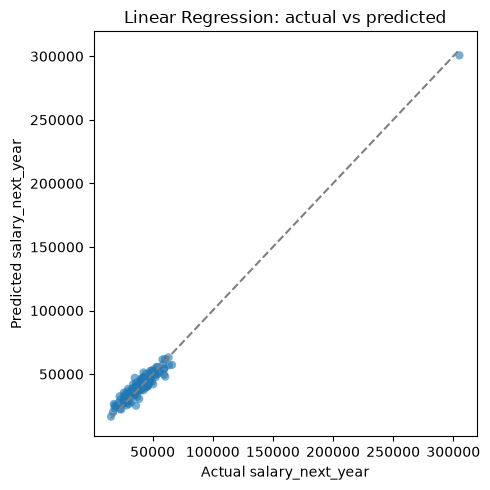

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_reg_test, pred_reg, alpha=0.6, edgecolor='none')
lims = [min(y_reg_test.min(), pred_reg.min()), max(y_reg_test.max(), pred_reg.max())]
ax.plot(lims, lims, linestyle='--', color='gray')
ax.set_xlabel('Actual salary_next_year')
ax.set_ylabel('Predicted salary_next_year')
ax.set_title('Linear Regression: actual vs predicted')
plt.tight_layout()
plt.show()


## 8. Classification -- comparing multiple algorithms

Same `X_train_processed` / `X_test_processed` used for every model below -- the preprocessing was fit once, and every algorithm just reuses it, predicting `purchased_premium`.

In [13]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier(random_state=42),
}

results = []
for name, clf in classifiers.items():
    clf.fit(X_train_processed, y_clf_train)
    preds = clf.predict(X_test_processed)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_clf_test, preds),
        'Precision': precision_score(y_clf_test, preds, zero_division=0),
        'Recall': recall_score(y_clf_test, preds, zero_division=0),
        'F1': f1_score(y_clf_test, preds, zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.683333,0.717391,0.568966,0.634615
1,Random Forest,0.675000,0.686275,0.603448,0.642202
2,SVM,0.666667,0.673077,0.603448,0.636364
3,KNN,0.641667,0.666667,0.517241,0.582524
4,Decision Tree,0.625000,0.622642,0.568966,0.594595
5,Naive Bayes,0.575000,0.629630,0.293103,0.400000


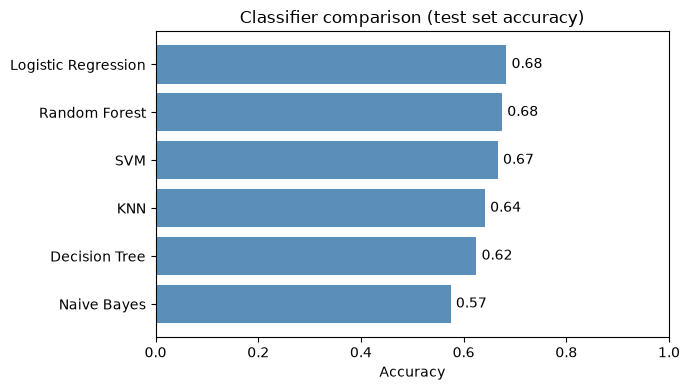

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(results_df['Model'], results_df['Accuracy'], color='#5B8FB9')
ax.set_xlabel('Accuracy')
ax.set_xlim(0, 1)
ax.set_title('Classifier comparison (test set accuracy)')
ax.invert_yaxis()
for i, v in enumerate(results_df['Accuracy']):
    ax.text(v + 0.01, i, f"{v:.2f}", va='center')
plt.tight_layout()
plt.show()


## 9. Bonus -- one deployable end-to-end pipeline

For shipping a single model, it's often cleaner to wrap preprocessing *and* the model together in one `Pipeline`, fit it on raw `X_train`, and save that one object.

In [15]:
final_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', LogisticRegression(max_iter=1000))
])

final_pipeline.fit(X_train, y_clf_train)
print("Test accuracy:", round(final_pipeline.score(X_test, y_clf_test), 3))

joblib.dump(final_pipeline, 'final_pipeline.pkl')
print("Saved final_pipeline.pkl -- preprocessing + model in one deployable object")


Test accuracy: 0.683
Saved final_pipeline.pkl -- preprocessing + model in one deployable object


## What's next

This used a single train/validation-style split. The natural next step -- once we bring it in -- is **k-fold cross-validation**, which repeats this same fit-on-train-only discipline across multiple folds instead of one split, giving a more stable estimate of how each algorithm really performs.